In [1]:
# 1) Imports and paths
from pathlib import Path
import pandas as pd
from lexos.dtm import DTM, Vectorizer
from sklearn.svm import SVC
from lexos.classification import trainer
import lexos.corpus.corpus_stats as cs

BASE = Path.cwd()  # run this notebook from doc_src/docs/tutorials/classification
DATA = BASE / "fed_papers"

print("Base:", BASE)
print("Data dir exists:", DATA.exists())

Base: c:\Users\gabal\LocalFiles\Lexos_Independant_Research\uv_lexos\doc_src\docs\tutorials\classification
Data dir exists: True


In [2]:
# 2) Collect train and test files
train_dirs = ["HAMILTON", "MADISON"]
test_dirs = ["COAUTHORED", "DISPUTED"]

train_files = []
for d in train_dirs:
    train_files.extend(sorted((DATA / d).glob("*.txt")))

test_files = []
for d in test_dirs:
    test_files.extend(sorted((DATA / d).glob("*.txt")))

print("Train files:", len(train_files), "Test files:", len(test_files))
assert train_files and test_files, "No files found; check working directory and folder structure."

Train files: 65 Test files: 15


In [3]:
# 3) Scrubber + Tokenizer
from lexos.scrubber.scrubber import Scrubber
from lexos.tokenizer import Tokenizer

scrubber = Scrubber()
scrubber.add_pipe("lower_case")
scrubber.add_pipe("digits")
scrubber.add_pipe("punctuation")

tokenizer = Tokenizer(model="en_core_web_sm")  # or any installed model

In [4]:
# 4) Build docs for CorpusStats (train + test)
from lexos.corpus.corpus_stats import CorpusStats

docs = []
raw_texts = []
sets_list = []
all_files = [*train_files, *test_files]

for f in all_files:
    raw = f.read_text(encoding="utf-8")
    clean = scrubber.scrub(raw)
    spacy_doc = tokenizer(clean)
    tokens = [t.text for t in spacy_doc if t.text.strip()]
    doc_id = f.name
    # label inside stats is doc_id (stats only)
    docs.append((doc_id, doc_id, tokens))
    raw_texts.append(raw)          # enables char_count if CorpusStats uses raw_texts
    sets_list.append(f.parent.name)

stats = CorpusStats(docs=docs, raw_texts=raw_texts)
stats_df = stats.doc_stats_df.copy()
stats_df.insert(0, "set", sets_list)

display(stats_df.head())
print("Available columns:", list(stats_df.columns))

,set,hapax_legomena,total_tokens,total_terms,vocabulary_density,hapax_dislegomena,char_count,word_count,unique_word_count,avg_word_length,ttr,hapax_legomenon_rate
Documents,,,,,,,,,,,,
FED_11_H.txt,HAMILTON,576,2503,835,33.36,106,14992,2503,835,5.989612,0.333600,0.230124
FED_12_H.txt,HAMILTON,555,2166,787,36.33,106,12948,2166,787,5.977839,0.363343,0.256233
FED_13_H.txt,HAMILTON,267,967,387,40.02,46,5770,967,387,5.966908,0.400207,0.276112
FED_15_H.txt,HAMILTON,752,3090,1044,33.79,132,18349,3090,1044,5.938188,0.337864,0.243366
FED_16_H.txt,HAMILTON,517,2042,722,35.36,93,12113,2042,722,5.931929,0.353575,0.253183


Available columns: ['set', 'hapax_legomena', 'total_tokens', 'total_terms', 'vocabulary_density', 'hapax_dislegomena', 'char_count', 'word_count', 'unique_word_count', 'avg_word_length', 'ttr', 'hapax_legomenon_rate']


In [5]:
# 5) Select feature columns from stats_df
feature_cols = [
    "char_count",
    "word_count",
    "unique_word_count",
    "avg_word_length",
    "ttr",
    "hapax_legomenon_rate",
]

train_mask = stats_df["set"].isin(["HAMILTON", "MADISON"])
test_mask  = stats_df["set"].isin(["COAUTHORED", "DISPUTED"])

X_train = stats_df.loc[train_mask, feature_cols].values
y_train = stats_df.loc[train_mask, "set"].values

X_test = stats_df.loc[test_mask, feature_cols].values
test_doc_ids = stats_df.loc[test_mask].index
test_sets = stats_df.loc[test_mask, "set"].values

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (65, 6) Test: (15, 6)


In [6]:
# 6) Train lexos Decision Tree via trainer
from lexos.classification import trainer

clf = trainer.fit_classifier(
    X_train,
    y_train,
    model="decision_tree",
    random_state=42,
    max_depth=4
)

print("Train accuracy:", clf.score(X_train, y_train))

Train accuracy: 0.9692307692307692


,feature,importance
3,avg_word_length,0.426645
5,hapax_legomenon_rate,0.333042
1,word_count,0.151966
0,char_count,0.070425
2,unique_word_count,0.017922
4,ttr,0.000000


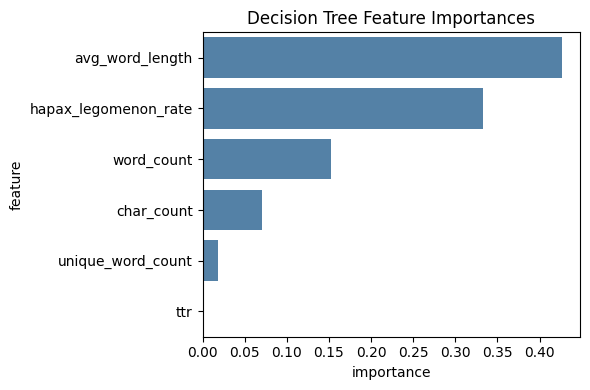

In [7]:
# 7) Feature importances
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

imp = clf.feature_importances_
imp_df = pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values("importance", ascending=False)
display(imp_df)

plt.figure(figsize=(6,4))
sns.barplot(data=imp_df, x="importance", y="feature", color="steelblue")
plt.title("Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

,feature,perm_mean,perm_std
3,avg_word_length,0.203077,0.038595
2,unique_word_count,0.157949,0.032498
0,char_count,0.117949,0.030598
5,hapax_legomenon_rate,0.098462,0.029620
1,word_count,0.074872,0.021660
4,ttr,0.000000,0.000000


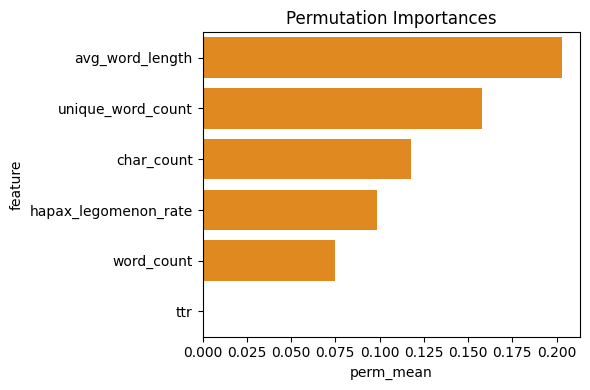

In [8]:
# 8) Permutation importance
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    clf,
    X_train,
    y_train,
    n_repeats=15,
    random_state=42,
    scoring="accuracy",
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "perm_mean": perm.importances_mean,
    "perm_std": perm.importances_std
}).sort_values("perm_mean", ascending=False)

display(perm_df)

plt.figure(figsize=(6,4))
sns.barplot(data=perm_df, x="perm_mean", y="feature", color="darkorange")
plt.title("Permutation Importances")
plt.tight_layout()
plt.show()

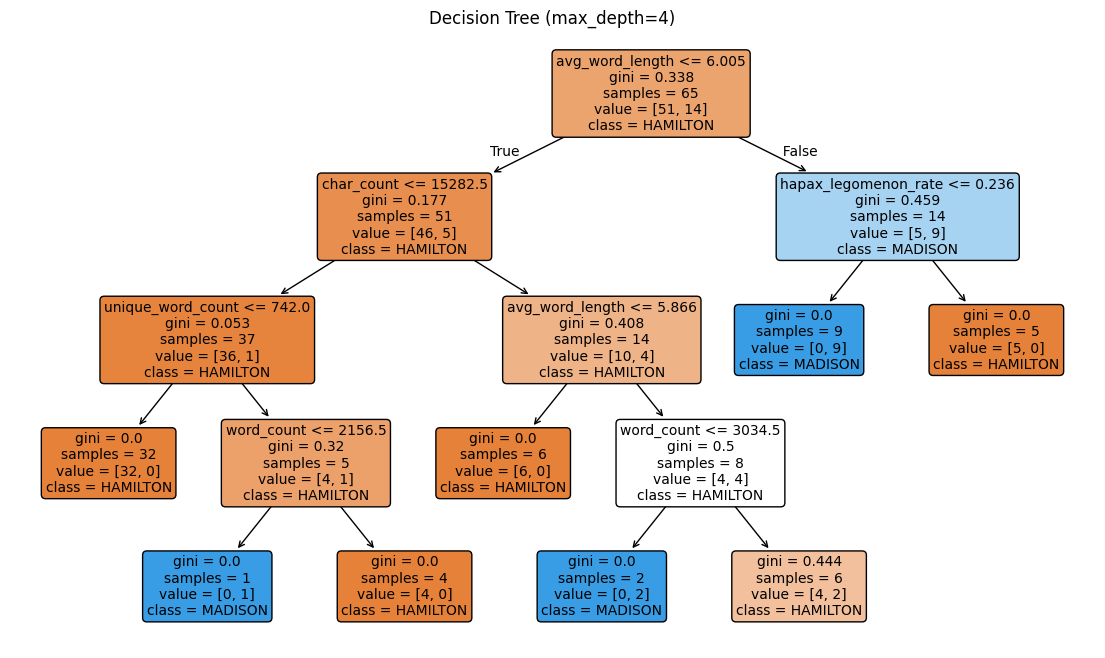

In [9]:
# 9) Visualize the tree
from sklearn.tree import plot_tree
plt.figure(figsize=(14,8))
plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=sorted(set(y_train)),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (max_depth=4)")
plt.show()

In [10]:
# 10) Predict on COAUTHORED / DISPUTED
y_pred_test = clf.predict(X_test)

pred_df = pd.DataFrame({
    "doc_id": test_doc_ids,
    "set": test_sets,
    "pred_author": y_pred_test
}).sort_values(["set", "doc_id"])

display(pred_df)
print("\nPrediction counts by set:")
print(pred_df.groupby(["set", "pred_author"]).size())

,doc_id,set,pred_author
0,FED_18_C.txt,COAUTHORED,HAMILTON
1,FED_19_C.txt,COAUTHORED,HAMILTON
2,FED_20_C.txt,COAUTHORED,HAMILTON
3,FED_49_D.txt,DISPUTED,MADISON
4,FED_50_D.txt,DISPUTED,HAMILTON
5,FED_51_D.txt,DISPUTED,MADISON
6,FED_52_D.txt,DISPUTED,HAMILTON
7,FED_53_D.txt,DISPUTED,HAMILTON
8,FED_54_D.txt,DISPUTED,HAMILTON
9,FED_55_D.txt,DISPUTED,HAMILTON



Prediction counts by set:
set         pred_author
COAUTHORED  HAMILTON       3
DISPUTED    HAMILTON       8
            MADISON        4
dtype: int64
